In [ ]:
import falnama
import matplotlib.pyplot as plt
import maxrf4u as mx
import re
import os

In [ ]:
os.getcwd()

In [ ]:
datastack_files = falnama.Falnama_maxrf_data().get_datastack_files()

In [ ]:
datastack_files

In [ ]:
def _get_object_name(datastack_file):
    return re.sub(r'.*(71803-\d\d).*', r'\1', datastack_file)

In [ ]:
for datastack_file in datastack_files[0]:
    ds = mx.DataStack(datastack_file)
    image = ds.read('imvis_reg')
    element_maps = ds.read('nmf_elementmaps')
    atom_nums = ds.read('nmf_atomnums')
    elements = mx.elems_from_atomnums(atom_nums)
    fig, axs = plt.subplots(nrows=4, ncols=5, figsize=[20,20])
    axs = axs.flatten()
    axs[0].imshow(image)
    axs[0].set_title(_get_object_name(datastack_file))
    for i, elemap in enumerate(element_maps):
        axs[i+1].imshow(elemap, vmin=0)
        axs[i+1].set_title(elements[i])
    axs[-1].remove()
    fig.savefig('./elemap_plots/'+_get_object_name(datastack_file)+'_elemaps', dpi=500 )

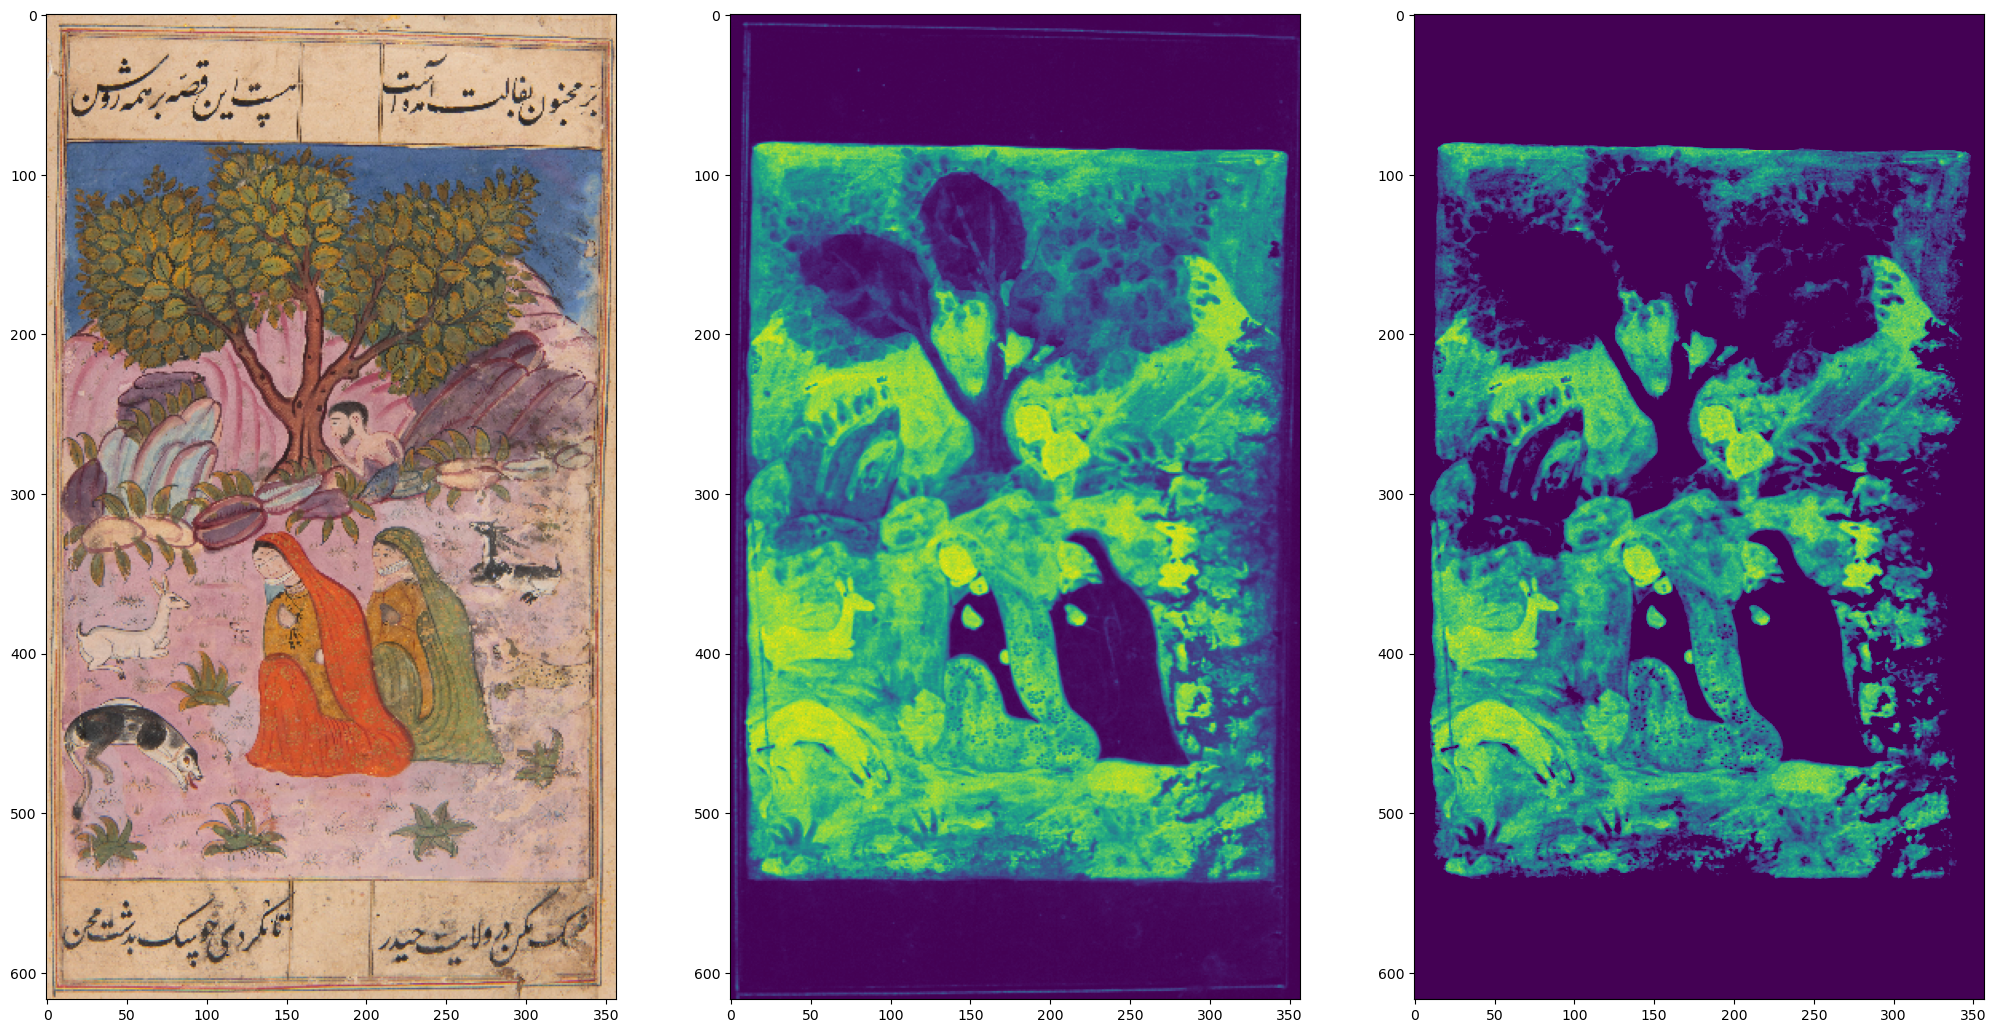

In [13]:
fig, axs = plt.subplots(nrows=1, ncols=3, figsize=[25,20])
axs = axs.flatten()

ds = mx.DataStack(datastack_files[-1])
image = ds.read('imvis_reg')
element_maps = ds.read('nmf_elementmaps')
atom_nums = ds.read('nmf_atomnums')
elements = mx.elems_from_atomnums(atom_nums)
axs[0].imshow(image)
axs[1].imshow(element_maps[-3])
axs[2].imshow(element_maps[-3], vmin=40)